In [2]:
# ============================================
# prescriptive_modeling_2011.ipynb
# ============================================

# ============================================
# Cell 1: Import Libraries & Load Data
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
import os

# Load dataset (relative to current notebook location)
df = pd.read_csv("../../data_processed/df_2011.csv")  # move up two levels

# Encode Urban_Rural as numeric
df["Urban_Rural_Code"] = df["Urban_Rural"].map({"Urban": 1, "Rural": 0})

# Display first rows
df.head()


,Zone,District,Urban_Rural,Total_Population,Male,Female,Literacy_Rate_Total,Literacy_Rate_Male,Literacy_Rate_Female,Literacy_Rate_Youth,...,Households_with_Electricity,Households_with_Radio,Households_with_TV,Households_with_Telephone,Electricity_Access_Rate,Radio_Access_Rate,TV_Access_Rate,Telephone_Access_Rate,Internet_Access_Rate,Urban_Rural_Code
0,Janakpur,Dhanusha,Urban,120000,60000,60000,66,72,60,82,...,18000,9000,12000,8500,81.818182,40.909091,54.545455,38.636364,25,1
1,Janakpur,Dhanusha,Rural,260000,130000,130000,59,65,53,77,...,26000,23000,10000,7000,54.166667,47.916667,20.833333,14.583333,7,0
2,Janakpur,Mahottari,Urban,90000,45000,45000,64,70,58,80,...,15000,7000,9500,6000,83.333333,38.888889,52.777778,33.333333,22,1
3,Janakpur,Mahottari,Rural,210000,105000,105000,57,63,51,74,...,22000,20000,8000,5000,52.380952,47.619048,19.047619,11.904762,6,0
4,Janakpur,Sarlahi,Urban,100000,50000,50000,65,71,59,81,...,16000,8000,11000,7000,80.000000,40.000000,55.000000,35.000000,20,1


In [3]:
# ============================================
# Cell 2: Define Thresholds for Prescriptive Analysis
# ============================================

# Thresholds for identifying digital divide gaps
literacy_thresh = 60
electricity_thresh = 60
radio_thresh = 40
tv_thresh = 50
telephone_thresh = 30
internet_thresh = 30

# Function to generate recommendations per district
def prescribe(row):
    recs = []
    if row["Literacy_Rate_Total"] < literacy_thresh:
        recs.append("Improve Literacy Programs")
    if row["Electricity_Access_Rate"] < electricity_thresh:
        recs.append("Expand Electricity Access")
    if row["Radio_Access_Rate"] < radio_thresh:
        recs.append("Increase Radio Access")
    if row["TV_Access_Rate"] < tv_thresh:
        recs.append("Provide TV/Media Access")
    if row["Telephone_Access_Rate"] < telephone_thresh:
        recs.append("Enhance Telephone Access")
    if "Internet_Access_Rate" in row and row["Internet_Access_Rate"] < internet_thresh:
        recs.append("Expand Internet Infrastructure")
    if not recs:
        recs.append("No major interventions needed")
    return ", ".join(recs)

# Apply to dataframe
df["Recommendations"] = df.apply(prescribe, axis=1)
df.head()


,Zone,District,Urban_Rural,Total_Population,Male,Female,Literacy_Rate_Total,Literacy_Rate_Male,Literacy_Rate_Female,Literacy_Rate_Youth,...,Households_with_Radio,Households_with_TV,Households_with_Telephone,Electricity_Access_Rate,Radio_Access_Rate,TV_Access_Rate,Telephone_Access_Rate,Internet_Access_Rate,Urban_Rural_Code,Recommendations
0,Janakpur,Dhanusha,Urban,120000,60000,60000,66,72,60,82,...,9000,12000,8500,81.818182,40.909091,54.545455,38.636364,25,1,Expand Internet Infrastructure
1,Janakpur,Dhanusha,Rural,260000,130000,130000,59,65,53,77,...,23000,10000,7000,54.166667,47.916667,20.833333,14.583333,7,0,"Improve Literacy Programs, Expand Electricity ..."
2,Janakpur,Mahottari,Urban,90000,45000,45000,64,70,58,80,...,7000,9500,6000,83.333333,38.888889,52.777778,33.333333,22,1,"Increase Radio Access, Expand Internet Infrast..."
3,Janakpur,Mahottari,Rural,210000,105000,105000,57,63,51,74,...,20000,8000,5000,52.380952,47.619048,19.047619,11.904762,6,0,"Improve Literacy Programs, Expand Electricity ..."
4,Janakpur,Sarlahi,Urban,100000,50000,50000,65,71,59,81,...,8000,11000,7000,80.000000,40.000000,55.000000,35.000000,20,1,Expand Internet Infrastructure


In [4]:
# ============================================
# Cell 3: Summary Table of Recommendations by District
# ============================================
summary = df.groupby(["Zone", "District", "Urban_Rural"])["Recommendations"].first().reset_index()
summary


,Zone,District,Urban_Rural,Recommendations
0,Janakpur,Dhanusha,Rural,"Improve Literacy Programs, Expand Electricity ..."
1,Janakpur,Dhanusha,Urban,Expand Internet Infrastructure
2,Janakpur,Mahottari,Rural,"Improve Literacy Programs, Expand Electricity ..."
3,Janakpur,Mahottari,Urban,"Increase Radio Access, Expand Internet Infrast..."
4,Janakpur,Sarlahi,Rural,"Improve Literacy Programs, Expand Electricity ..."
5,Janakpur,Sarlahi,Urban,Expand Internet Infrastructure
6,Narayani,Bara,Rural,"Expand Electricity Access, Provide TV/Media Ac..."
7,Narayani,Bara,Urban,Expand Internet Infrastructure
8,Narayani,Parsa,Rural,"Expand Electricity Access, Provide TV/Media Ac..."
9,Narayani,Parsa,Urban,Increase Radio Access


<Figure size 1200x600 with 0 Axes>

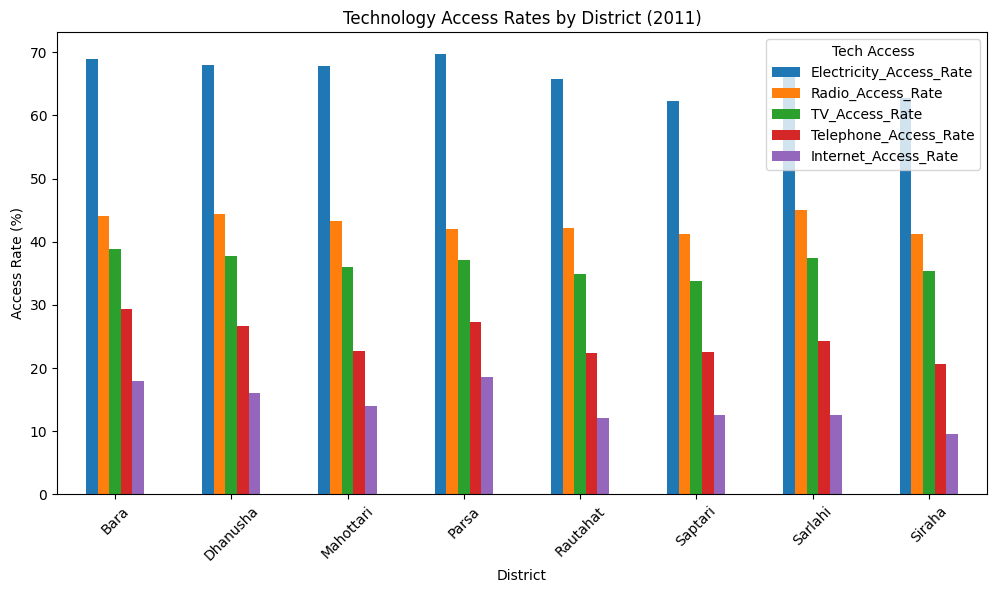

In [5]:
# ============================================
# Cell 4: Visualize Key Technology Gaps
# ============================================
tech_cols = ["Electricity_Access_Rate", "Radio_Access_Rate", "TV_Access_Rate", "Telephone_Access_Rate"]
if "Internet_Access_Rate" in df.columns:
    tech_cols.append("Internet_Access_Rate")

plt.figure(figsize=(12,6))
df_grouped = df.groupby("District")[tech_cols].mean()
df_grouped.plot(kind="bar", figsize=(12,6))
plt.title("Technology Access Rates by District (2011)")
plt.ylabel("Access Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Tech Access")
plt.show()


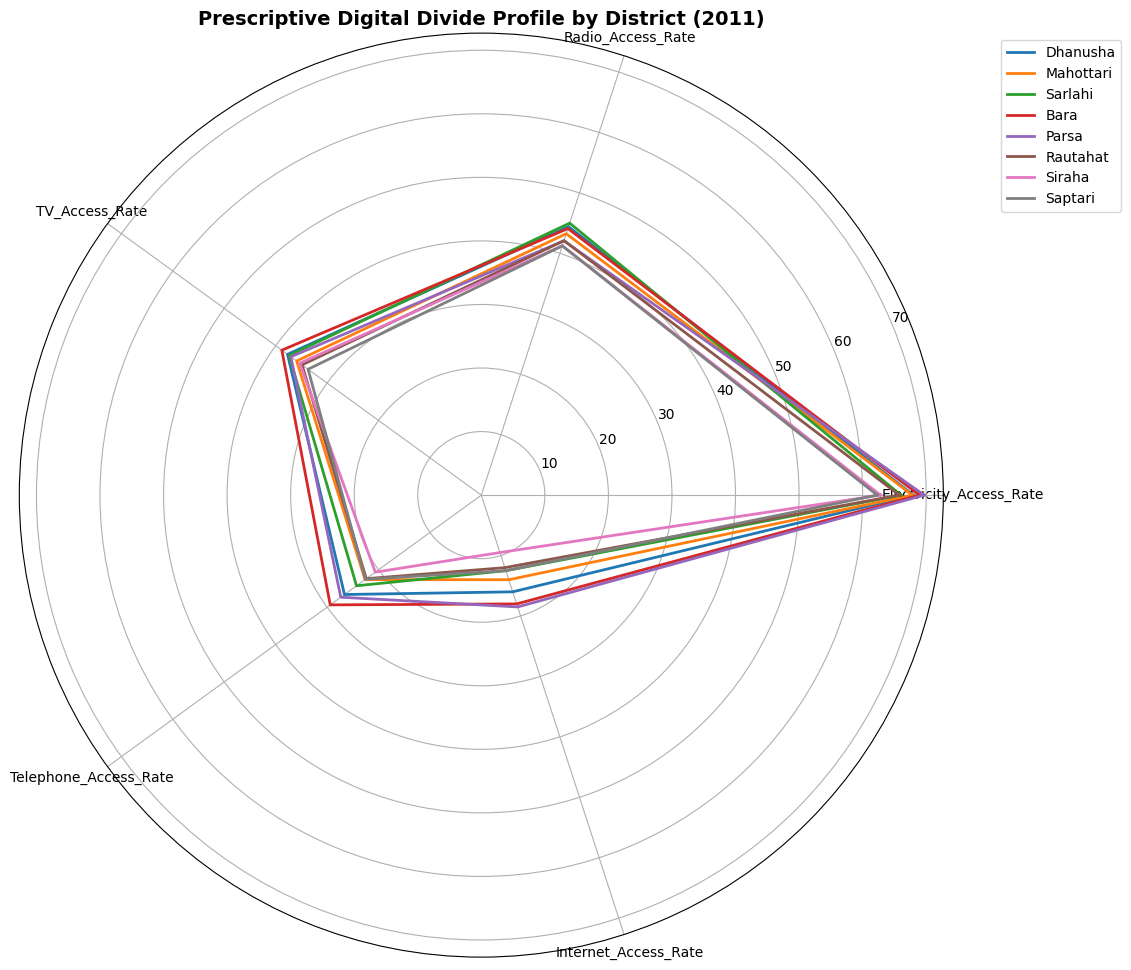

In [6]:
# ============================================
# Cell 5: Prescriptive Radar Charts for Each District
# ============================================
categories = tech_cols
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

districts = df["District"].unique()

plt.figure(figsize=(12,12))
for district in districts:
    subset = df[df["District"] == district][categories].mean().tolist()
    subset += subset[:1]  # close the loop
    plt.polar(angles, subset, label=district, linewidth=2)

plt.xticks(angles[:-1], categories, fontsize=10)
plt.title("Prescriptive Digital Divide Profile by District (2011)", size=14, weight="bold")
plt.legend(bbox_to_anchor=(1.2, 1))
plt.show()


In [7]:
# ============================================
# Cell 6: Export Prescriptions
# ============================================
# Ensure reports folder exists
os.makedirs("../../reports", exist_ok=True)

# Save recommendations
df[["Zone","District","Urban_Rural","Recommendations"]].to_csv("../../reports/prescriptions_2011.csv", index=False)
print("Recommendations exported to ../../reports/prescriptions_2011.csv")


Recommendations exported to ../../reports/prescriptions_2011.csv
